# Verificación de locutor de texto dependiente

Proyecto de Biometría de la Voz. El objetivo es construir un sistema que, dado un
audio de una persona diciendo una frase corta predefinida, sea capaz de:

1. **Identificar al locutor** — ¿quién está hablando? (Red 1)
2. **Verificar la frase** — ¿ha dicho la frase esperada? (Red 2)

Este notebook es el *orquestador*: no contiene la lógica interna, solo llama en
orden a las funciones de los módulos `src/data.py`, `src/model.py` y
`src/train.py`, y muestra los resultados.

## Base de datos

Usamos `TextDependentSpeakerIdentification`: 816 locutores que pronuncian 5
frases cortas predefinidas (S1–S5), unos 45.000 audios en total a 16 kHz.

Por viabilidad computacional (RTX 3060 Laptop, 6 GB) trabajamos con un
**subconjunto de los primeros 50 locutores** (orden alfabético). Esto nos deja
unos **2.500 audios**, ~10 por locutor y frase, repartidos en:

- **50 clases de locutor** para la Red 1.
- **5 clases de frase** (S1–S5) para la Red 2.

## 1. Preparación del entorno y carga de datos

Importamos los módulos del proyecto. La línea `sys.path.append("src")` le dice a
Python que busque también en la carpeta `src/`, que es donde están nuestros
módulos.

A continuación cargamos el dataset. Procesar los ~2.500 audios (leer cada WAV
y extraer sus MFCC) tarda un par de minutos, así que usamos una **caché**: la
primera vez se procesa todo y se guarda en un fichero `cache_dataset.npz`; las
siguientes veces se carga directamente de ahí, en segundos.

> Si cambias el subconjunto de locutores (`max_locutores`), borra antes
> `cache_dataset.npz` para forzar la regeneración.

In [1]:
import sys, os
sys.path.append("src")

import numpy as np
import data, model, train

CACHE = "cache_dataset.npz"
N_LOCUTORES = 50   # subconjunto de trabajo

if os.path.exists(CACHE):
    # La caché ya existe: cargamos de disco (rápido)
    d = np.load(CACHE, allow_pickle=True)
    X, y_loc, y_pin = d["X"], d["y_loc"], d["y_pin"]
    mapas     = d["mapas"].item()
    registros = d["registros"].tolist()
    print("Dataset cargado de la caché:", X.shape)
else:
    # Primera vez: procesamos los audios y guardamos la caché
    registros = data.construir_indice(max_locutores=N_LOCUTORES,criterio="mas_audios")
    X, y_loc, y_pin, mapas = data.construir_dataset(registros)
    np.savez(CACHE, X=X, y_loc=y_loc, y_pin=y_pin,
             mapas=mapas, registros=registros)
    print("Dataset procesado y guardado en caché:", X.shape)

2026-05-20 21:06:57.634630: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-20 21:06:57.649153: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-20 21:06:57.653578: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-20 21:06:57.665490: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Dataset cargado de la caché: (7574, 120, 63, 1)


In [2]:
# Comprobación de coherencia: que la caché coincide con lo esperado
print(f"Audios totales : {X.shape[0]}")
print(f"Forma MFCC     : {X.shape[1:]}  (n_caract, T, canal)")
print(f"Locutores      : {len(mapas['locutor'])}  (esperados: {N_LOCUTORES})")
print(f"Frases         : {len(mapas['pin'])}      (esperadas: 5)")

assert len(mapas["locutor"]) == N_LOCUTORES, \
    "La caché no coincide con N_LOCUTORES. ¿Has olvidado borrar cache_dataset.npz?"
assert len(mapas["pin"]) == 5, "Esperábamos 5 frases (S1–S5)."

Audios totales : 7574
Forma MFCC     : (120, 63, 1)  (n_caract, T, canal)
Locutores      : 50  (esperados: 50)
Frases         : 5      (esperadas: 5)


## 2. Red 1 — Identificación del locutor

La primera red responde a la pregunta *"¿quién está hablando?"*. Es una **CNN**
(red convolucional) con **50 salidas**, una por cada locutor del subconjunto.

### División de los datos

Dividimos los audios en tres grupos:

- **Train (70 %)**: la red aprende con ellos.
- **Validación (15 %)**: vigilamos el entrenamiento sin que la red aprenda de
  ellos; sirve para detectar sobreajuste.
- **Test (15 %)**: no se tocan hasta el final; dan la medida honesta del
  rendimiento.

La división es **estratificada por locutor**: cada locutor aparece en los tres
grupos en la misma proporción. Dividimos los *registros* (rutas de fichero), no
los MFCC ya calculados, porque así podemos aplicar el aumento de datos sobre
los audios crudos antes de extraer sus características.

In [4]:
# Dividimos los REGISTROS (rutas + etiquetas), estratificando por locutor.
reg_train, reg_val, reg_test = data.dividir_registros(registros, campo="locutor")

Registros divididos -> train: 5301  |  val: 1136  |  test: 1137


### Aumento de datos (solo en train)

Para combatir el sobreajuste, generamos variaciones artificiales de los audios
de entrenamiento (ruido suave, desplazamiento temporal, cambio de velocidad).
Por cada audio original se crean **2 copias aumentadas**, así la red ve el
triple de ejemplos y se ve forzada a generalizar.

**No usamos cambio de tono (pitch shift)** a propósito: el tono es un rasgo de
la identidad del locutor, y desplazarlo difuminaría justo lo que esta red debe
aprender. (Para la Red 2 sería inofensivo, pero allí no nos hace falta.)

**El aumento se aplica solo a train.** Validación y test se procesan sin
aumento, para que midan el rendimiento sobre audios reales y la métrica sea
honesta.

In [6]:
# Train CON aumento (originales + 2 copias aumentadas por audio)
print("Construyendo train (con aumento)...")
Xtr, ytr, ytr_pin = data.construir_dataset_desde_registros(
    reg_train, mapas, aumentar=True, n_aug=2)

# Validación y test SIN aumento
print("\nConstruyendo validación...")
Xv, yv, yv_pin = data.construir_dataset_desde_registros(
    reg_val, mapas, aumentar=False)

print("\nConstruyendo test...")
Xte, yte, yte_pin = data.construir_dataset_desde_registros(
    reg_test, mapas, aumentar=False)

print(f"\nTrain: {Xtr.shape}  |  Val: {Xv.shape}  |  Test: {Xte.shape}")

Construyendo train (con aumento)...
  Procesando audio 0/5301...
  Procesando audio 250/5301...
  Procesando audio 500/5301...
  Procesando audio 750/5301...
  Procesando audio 1000/5301...
  Procesando audio 1250/5301...
  Procesando audio 1500/5301...
  Procesando audio 1750/5301...
  Procesando audio 2000/5301...
  Procesando audio 2250/5301...
  Procesando audio 2500/5301...
  Procesando audio 2750/5301...
  Procesando audio 3000/5301...
  Procesando audio 3250/5301...
  Procesando audio 3500/5301...
  Procesando audio 3750/5301...
  Procesando audio 4000/5301...
  Procesando audio 4250/5301...
  Procesando audio 4500/5301...
  Procesando audio 4750/5301...
  Procesando audio 5000/5301...
  Procesando audio 5250/5301...
  Construido: (15903, 120, 63, 1) (con aumento x2)

Construyendo validación...
  Procesando audio 0/1136...
  Procesando audio 250/1136...
  Procesando audio 500/1136...
  Procesando audio 750/1136...
  Procesando audio 1000/1136...
  Construido: (1136, 120, 63, 1)


### Creación y entrenamiento del modelo

Creamos la CNN con `model.construir_modelo`. Le pasamos:

- `"cnn"`: el tipo de arquitectura (la otra opción es `"cnn_lstm"`).
- `input_shape`: la forma de cada audio (n.º de características × tiempo × canal).
- `n_clases=50`: una salida por locutor.

Después la entrenamos. Cada *época* es una pasada completa por los datos de
train. El entrenamiento se detiene solo (EarlyStopping) cuando la red deja de
mejorar en validación, y restaura los mejores pesos.

> **Expectativa:** con 24 locutores la red anterior llegó al 93,73 % en test.
> Ahora con 50 locutores y menos audios por locutor (~35 en train tras los
> splits) es esperable que el accuracy baje algo. Lo justificaremos en la
> memoria: más clases, menos ejemplos por clase, problema más difícil.

In [7]:
# Config de entrenamiento ajustado para esta Red 1:
#   - monitor val_loss (más suave que val_accuracy con 50 clases)
#   - patience 20 (curva de val ruidosa, le damos más margen)
#   - epochs 100 (con la patience nueva no se va a desbocar)
#   - batch 64 (gradientes más estables)
cfg_red1 = {
    "batch_size":    64,
    "epochs":        100,
    "learning_rate": 1e-3,
    "patience":      20,
    "monitor":       "val_loss",
    "results_dir":   "resultados",
}

# Creamos la CNN: 50 clases (una por locutor)
red1 = model.construir_modelo("cnn", input_shape=X.shape[1:], n_clases=50)

# La entrenamos. Guarda la mejor versión en resultados/red1_locutor.keras
hist1 = train.entrenar(red1, Xtr, ytr, Xv, yv,
                       cfg=cfg_red1,
                       ruta_modelo="resultados/red1_locutor.keras")

I0000 00:00:1779311478.900261    9678 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1779311478.916169    9678 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1779311478.917541    9678 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1779311478.920341    9678 cuda_executor.cc:1015] successful NUMA node read from SysFS ha


Entrenando 'CNN'...
  Train: 15903  |  Val: 1136
  Batch: 64  |  Épocas máx: 100



2026-05-20 21:11:19.800372: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 480906720 exceeds 10% of free system memory.


Epoch 1/100


I0000 00:00:1779311481.869188    9798 service.cc:146] XLA service 0x76393c011870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779311481.869226    9798 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-05-20 21:11:21.914504: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-20 21:11:22.128078: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
2026-05-20 21:11:24.862768: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2257', 492 bytes spill stores, 492 bytes spill loads



  2/249 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.0195 - loss: 4.0720 

I0000 00:00:1779311492.463105    9798 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.0458 - loss: 3.8279 - val_accuracy: 0.0308 - val_loss: 4.5308
Epoch 2/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.1060 - loss: 3.3816 - val_accuracy: 0.1761 - val_loss: 3.0876
Epoch 3/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.1556 - loss: 3.1054 - val_accuracy: 0.0845 - val_loss: 3.9173
Epoch 4/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.2054 - loss: 2.9232 - val_accuracy: 0.1532 - val_loss: 3.1491
Epoch 5/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.2373 - loss: 2.7888 - val_accuracy: 0.2148 - val_loss: 2.9813
Epoch 6/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.2648 - loss: 2.6430 - val_accuracy: 0.2042 - val_loss: 2.8652
Epoch 7/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.3013 - loss: 2.5391 - val_accuracy: 0.1074 - val_loss: 4.3501
Epoch 8/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.3096 - loss: 2.4732 - val

### Evaluación de la Red 1

Entrenada la red, la evaluamos sobre el conjunto de **test** — audios que no
ha visto nunca. El resultado en test es la medida honesta del rendimiento.

Generamos dos figuras:

- **Curvas de entrenamiento**: accuracy y pérdida a lo largo de las épocas,
  comparando train y validación. Si se separan mucho, hay sobreajuste.
- **Matriz de confusión**: tabla que muestra, para cada locutor real, qué
  locutor predijo la red. La diagonal son los aciertos. Con 50 clases las
  anotaciones numéricas no caben dentro de las casillas, pero la diagonal se
  lee bien por color (`train.py` desactiva `annot` automáticamente si hay
  más de 25 clases).


=== Evaluación en TEST ===
  Pérdida  : 1.1121
  Accuracy : 72.21%

              precision    recall  f1-score   support

  spk_000008       0.93      0.50      0.65        26
  spk_000010       0.80      0.42      0.55        19
  spk_000014       0.67      0.95      0.78        19
  spk_000031       0.89      0.74      0.81        23
  spk_000067       0.75      0.41      0.53        22
  spk_000079       0.88      0.78      0.82        18
  spk_000113       0.94      0.84      0.89        19
  spk_000120       0.88      0.39      0.54        18
  spk_000125       0.83      0.56      0.67        18
  spk_000141       0.86      0.90      0.88        21
  spk_000149       0.83      0.93      0.88        27
  spk_000174       0.92      0.88      0.90        25
  spk_000193       0.65      0.92      0.76        24
  spk_000195       1.00      0.45      0.62        20
  spk_000197       0.77      0.50      0.61        20
  spk_000210       0.50      0.19      0.28        21
  spk_000212

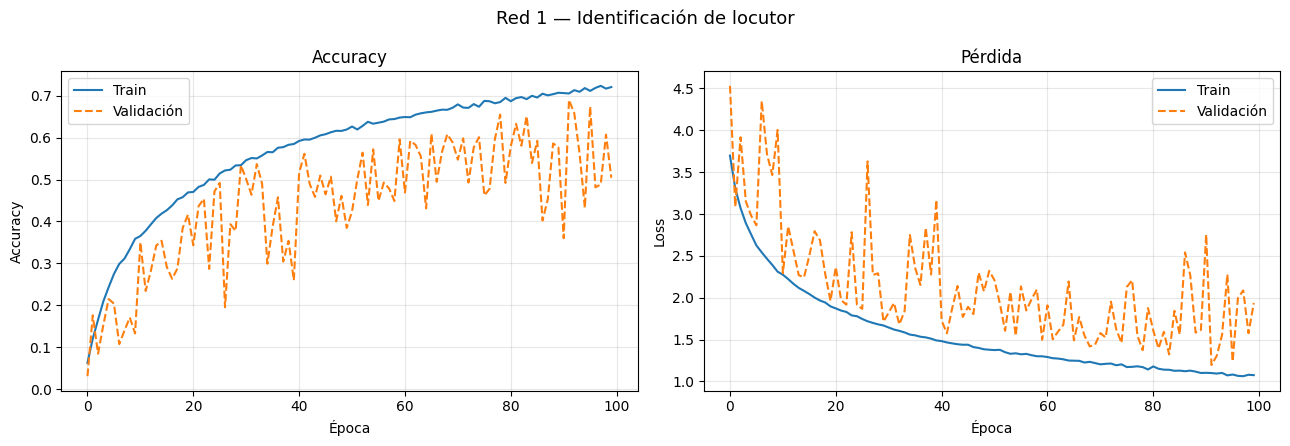

Matriz guardada en resultados/red1_matriz.png


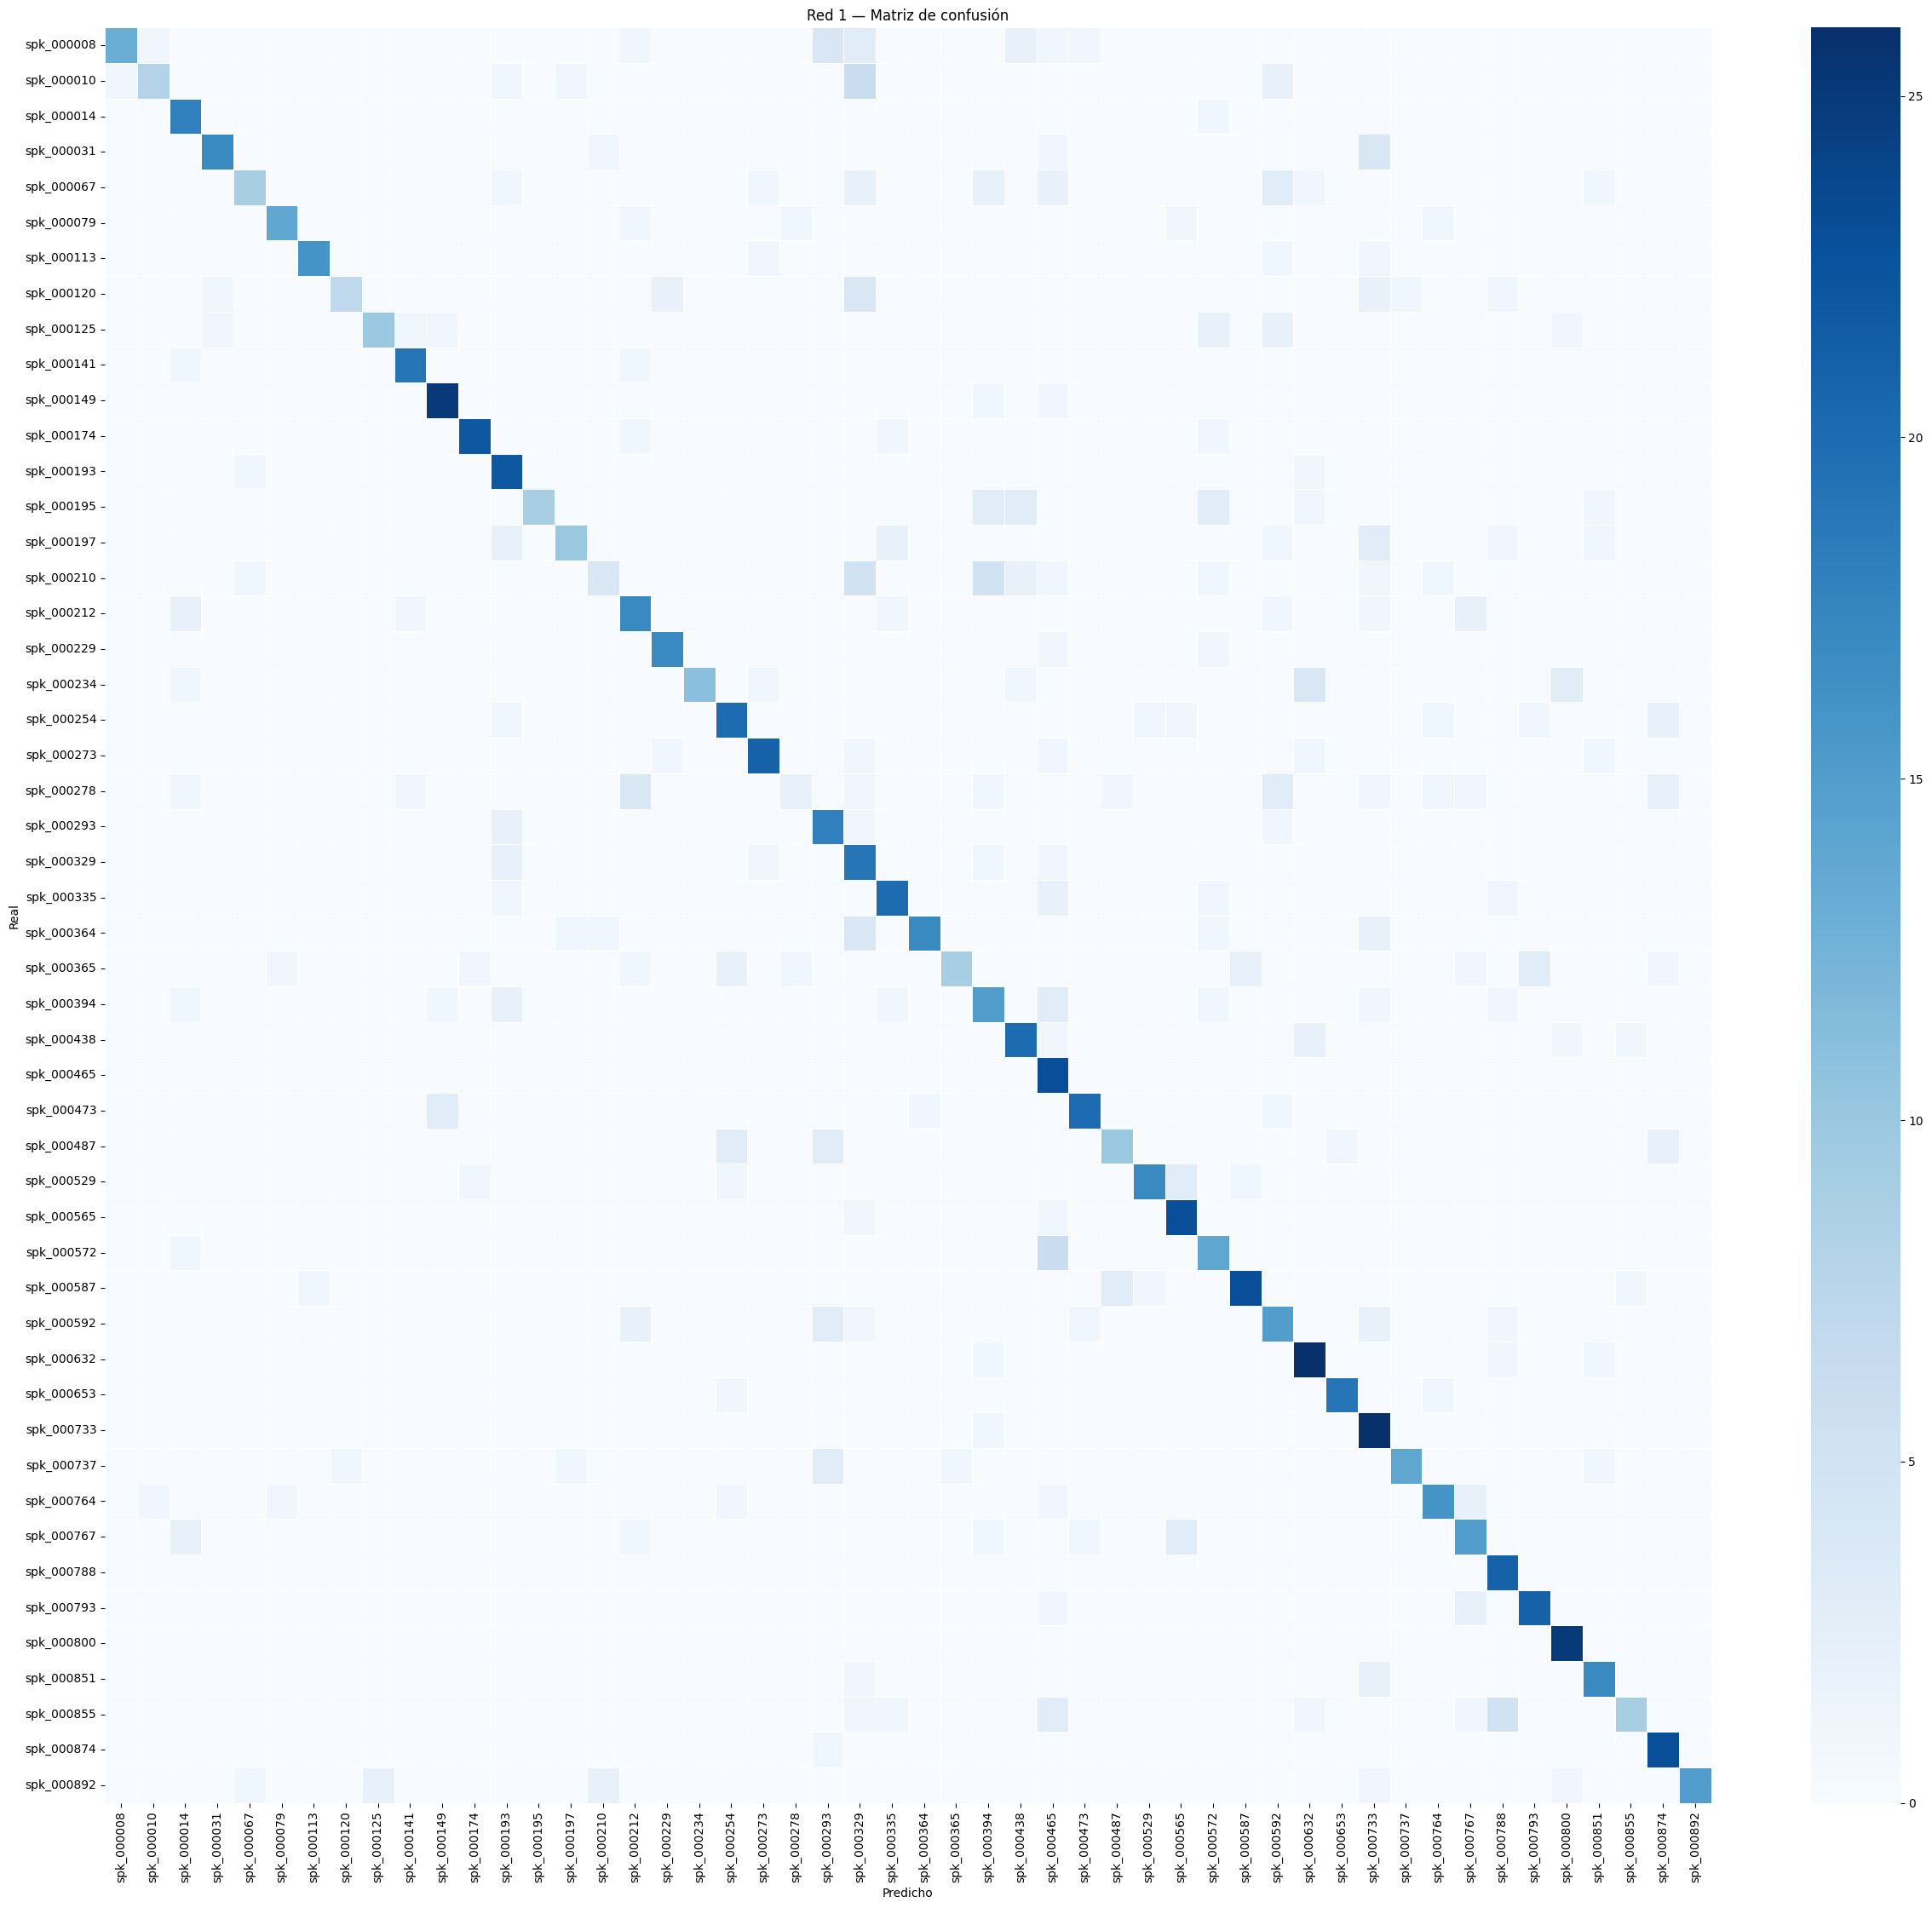

In [8]:
# Lista de nombres de locutor, ordenada igual que las etiquetas (alfabético)
nombres_loc = sorted(mapas["locutor"].keys())

# Evaluamos sobre el conjunto de test
res1 = train.evaluar(red1, Xte, yte, nombres_clases=nombres_loc)

# Curvas de entrenamiento
train.graficar_entrenamiento(
    hist1,
    titulo="Red 1 — Identificación de locutor",
    guardar="resultados/red1_curvas.png",
)

# Matriz de confusión
train.graficar_matriz_confusion(
    res1, nombres_loc,
    titulo="Red 1 — Matriz de confusión",
    guardar="resultados/red1_matriz.png",
)

## 3. Red 2 — Verificación de la frase

La segunda red responde a la pregunta *"¿qué frase se ha dicho?"*. Es una
**CNN** con **5 salidas**, una por cada frase de la base de datos (S1–S5).

Reutilizamos los mismos audios que en la Red 1: la diferencia está en la
etiqueta. Donde la Red 1 usaba la etiqueta de locutor, la Red 2 usa la
etiqueta de frase.

### División de los datos

Volvemos a dividir los registros en train / val / test, pero esta vez
**estratificando por frase** (`campo="pin"`): cada frase debe aparecer
proporcionalmente en los tres grupos.

Una consecuencia importante de cambiar el criterio de estratificación: un
locutor concreto puede caer entero en train o entero en test. Eso es justo
lo que queremos, porque la Red 2 tiene que reconocer qué frase se dice
**independientemente de quién la diga**, incluso si nunca había oído a ese
locutor. Es la propiedad de "generalización a locutores nuevos".

In [9]:
# Dividimos los registros estratificando por frase
reg_train2, reg_val2, reg_test2 = data.dividir_registros(registros, campo="pin")

Registros divididos -> train: 5301  |  val: 1136  |  test: 1137


### Construcción de los datasets

Esta vez no usamos aumento de datos: con 5 clases y unos 500 audios por clase
tenemos margen de sobra, el problema ya no es la falta de datos.

Usamos las etiquetas de PIN (`ytr_pin`, `yv_pin`, `yte_pin`) que devuelve
`construir_dataset_desde_registros` — la función ya nos las prepara en una
sola pasada.

In [11]:
# Sin aumento: las tres particiones son audios reales
print("Construyendo train...")
Xtr2, ytr2_loc, ytr2_pin = data.construir_dataset_desde_registros(
    reg_train2, mapas, aumentar=False)

print("\nConstruyendo validación...")
Xv2, yv2_loc, yv2_pin = data.construir_dataset_desde_registros(
    reg_val2, mapas, aumentar=False)

print("\nConstruyendo test...")
Xte2, yte2_loc, yte2_pin = data.construir_dataset_desde_registros(
    reg_test2, mapas, aumentar=False)

print(f"\nTrain: {Xtr2.shape}  |  Val: {Xv2.shape}  |  Test: {Xte2.shape}")

Construyendo train...
  Procesando audio 0/5301...
  Procesando audio 250/5301...
  Procesando audio 500/5301...
  Procesando audio 750/5301...
  Procesando audio 1000/5301...
  Procesando audio 1250/5301...
  Procesando audio 1500/5301...
  Procesando audio 1750/5301...
  Procesando audio 2000/5301...
  Procesando audio 2250/5301...
  Procesando audio 2500/5301...
  Procesando audio 2750/5301...
  Procesando audio 3000/5301...
  Procesando audio 3250/5301...
  Procesando audio 3500/5301...
  Procesando audio 3750/5301...
  Procesando audio 4000/5301...
  Procesando audio 4250/5301...
  Procesando audio 4500/5301...
  Procesando audio 4750/5301...
  Procesando audio 5000/5301...
  Procesando audio 5250/5301...
  Construido: (5301, 120, 63, 1)

Construyendo validación...
  Procesando audio 0/1136...
  Procesando audio 250/1136...
  Procesando audio 500/1136...
  Procesando audio 750/1136...
  Procesando audio 1000/1136...
  Construido: (1136, 120, 63, 1)

Construyendo test...
  Procesan

### Creación y entrenamiento del modelo

CNN idéntica a la Red 1, pero con `n_clases=5`. Configuración más ligera
porque el problema es más fácil:

- **Monitor `val_accuracy`**: con 5 clases la curva de val_accuracy es
  estable (a diferencia de la Red 1, donde era ruidosa por el alto número
  de clases).
- **Patience 10, epochs 40**: convergencia rápida esperada.
- **Sin aumento**: ya tenemos ~500 audios por clase, sobra margen.

In [12]:
cfg_red2 = {
    "batch_size":    64,
    "epochs":        40,
    "learning_rate": 1e-3,
    "patience":      10,
    "monitor":       "val_accuracy",
    "results_dir":   "resultados",
}

# CNN de 5 clases (una por frase)
red2 = model.construir_modelo("cnn", input_shape=X.shape[1:], n_clases=5)

# Entrenamos
hist2 = train.entrenar(red2, Xtr2, ytr2_pin, Xv2, yv2_pin,
                       cfg=cfg_red2,
                       ruta_modelo="resultados/red2_frase.keras")


Entrenando 'CNN'...
  Train: 5301  |  Val: 1136
  Batch: 64  |  Épocas máx: 40

Epoch 1/40


2026-05-20 21:32:10.193435: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 160302240 exceeds 10% of free system memory.
2026-05-20 21:32:10.350474: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 160302240 exceeds 10% of free system memory.


81/83 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4428 - loss: 1.3561

2026-05-20 21:32:17.560495: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1532', 8 bytes spill stores, 8 bytes spill loads

2026-05-20 21:32:18.563020: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2257', 436 bytes spill stores, 436 bytes spill loads



83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.4467 - loss: 1.3485 - val_accuracy: 0.2033 - val_loss: 4.3073
Epoch 2/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7180 - loss: 0.7731 - val_accuracy: 0.2033 - val_loss: 5.2132
Epoch 3/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8123 - loss: 0.5630 - val_accuracy: 0.2033 - val_loss: 3.0121
Epoch 4/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8691 - loss: 0.4241 - val_accuracy: 0.3275 - val_loss: 2.1319
Epoch 5/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8959 - loss: 0.3517 - val_accuracy: 0.4701 - val_loss: 1.9600
Epoch 6/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9106 - loss: 0.3122 - val_accuracy: 0.7016 - val_loss: 0.9156
Epoch 7/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9240 - loss: 0.2664 - val_accuracy: 0.4454 - val_loss: 3.0752
Epoch 8/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9318 - loss: 0.2361 - val_accuracy: 0.2861 - val_loss: 

### Evaluación de la Red 2

Evaluamos sobre test y generamos las dos figuras: curvas de entrenamiento
y matriz de confusión.

Con solo 5 clases, la matriz de confusión se lee de un vistazo y nos dice
exactamente qué frases (si alguna) se confunden entre sí. Una matriz casi
diagonal es lo esperado aquí.


=== Evaluación en TEST ===
  Pérdida  : 0.2854
  Accuracy : 92.17%

              precision    recall  f1-score   support

          S1       1.00      0.88      0.94       231
          S2       0.80      1.00      0.89       231
          S3       0.89      0.96      0.92       227
          S4       0.98      0.89      0.93       228
          S5       0.99      0.89      0.94       220

    accuracy                           0.92      1137
   macro avg       0.93      0.92      0.92      1137
weighted avg       0.93      0.92      0.92      1137

Curvas guardadas en resultados/red2_curvas.png


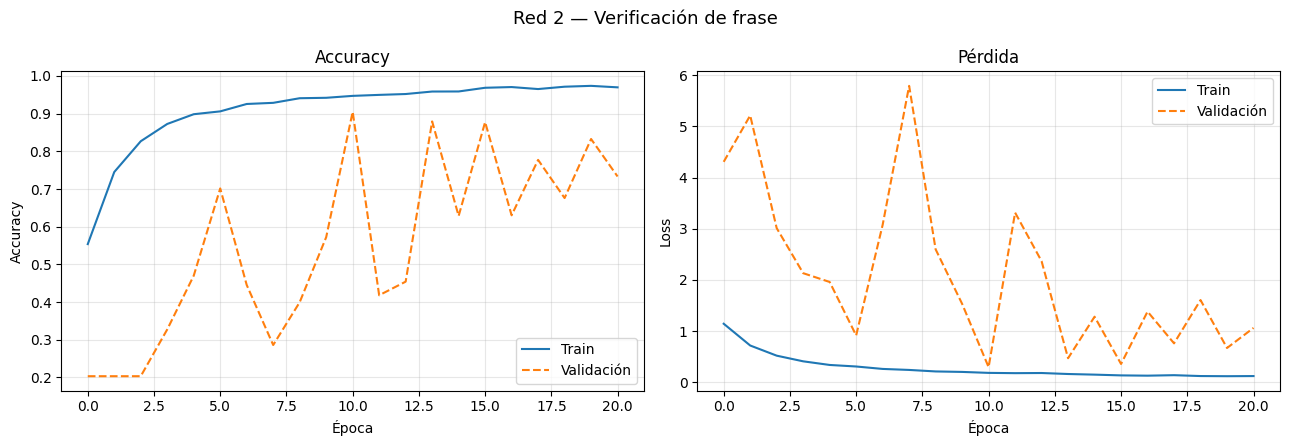

Matriz guardada en resultados/red2_matriz.png


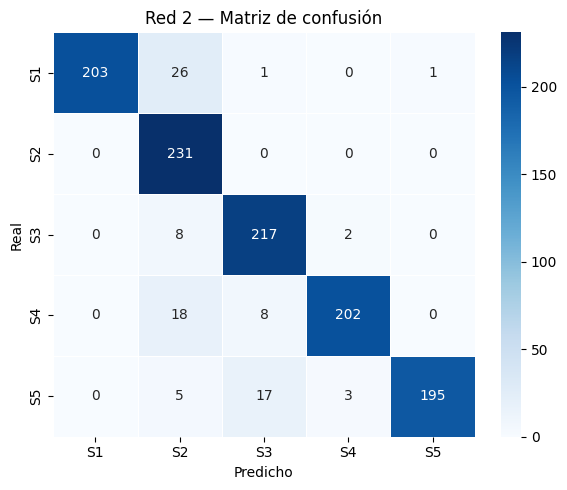

In [13]:
# Nombres de frase, ordenados igual que las etiquetas
nombres_pin = sorted(mapas["pin"].keys())

# Evaluamos sobre test
res2 = train.evaluar(red2, Xte2, yte2_pin, nombres_clases=nombres_pin)

# Curvas
train.graficar_entrenamiento(
    hist2,
    titulo="Red 2 — Verificación de frase",
    guardar="resultados/red2_curvas.png",
)

# Matriz de confusión
train.graficar_matriz_confusion(
    res2, nombres_pin,
    titulo="Red 2 — Matriz de confusión",
    guardar="resultados/red2_matriz.png",
)